In [1]:
# Install Optuna (only needed once per environment)
!pip install optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 26.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial spam

from xgboost import XGBClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, f1_score,
)
from sklearn.preprocessing import LabelEncoder

# ── Global random seed ────────────────────────────────────────────────────────
# One constant controls ALL random operations → same results every run.
RANDOM_SEED = 42

In [3]:
df = pd.read_csv("/content/ILPD_robust_scaled_with_gmm_noise.csv")

X = df.drop(columns=["Result"])
y = df["Result"]

# XGBoost expects 0-indexed labels → encode {1,2} → {0,1}
le = LabelEncoder()
y_enc = le.fit_transform(y)          # 1→0, 2→1
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print(f"Class distribution: {dict(zip(*np.unique(y_enc, return_counts=True)))}\n")

Class mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}
Class distribution: {np.int64(0): np.int64(487), np.int64(1): np.int64(197)}



In [4]:
df.shape

(684, 12)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc        # preserve class ratio in both splits
)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}\n")

Train size: 547  |  Test size: 137



In [6]:
scale_pos_weight = (y_enc == 0).sum() / (y_enc == 1).sum()   # handle class imbalance

model = XGBClassifier(
    n_estimators       = 300,
    max_depth          = 4,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    scale_pos_weight   = scale_pos_weight,   # compensates class imbalance
    use_label_encoder  = False,
    eval_metric        = "logloss",
    random_state       = 42,
    n_jobs             = -1
)

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    model, X, y_enc,
    cv      = skf,
    scoring = ["accuracy", "f1_weighted", "roc_auc"],
    return_train_score=True
)

print("  5-FOLD STRATIFIED CROSS-VALIDATION RESULTS")
metrics = {
    "Accuracy"   : "test_accuracy",
    "F1-weighted": "test_f1_weighted",
    "ROC-AUC"    : "test_roc_auc",
}
for label, key in metrics.items():
    vals = cv_results[key]
    print(f"  {label:15s}:  {vals.mean():.4f}  ±  {vals.std():.4f}   "
          f"(folds: {', '.join(f'{v:.3f}' for v in vals)})")
print("=" * 55 + "\n")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:14:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:14:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:14:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:14:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

  5-FOLD STRATIFIED CROSS-VALIDATION RESULTS
  Accuracy       :  0.7135  ±  0.0165   (folds: 0.693, 0.693, 0.730, 0.723, 0.728)
  F1-weighted    :  0.7176  ±  0.0141   (folds: 0.704, 0.698, 0.733, 0.729, 0.725)
  ROC-AUC        :  0.7591  ±  0.0232   (folds: 0.743, 0.724, 0.790, 0.771, 0.768)



In [8]:
model.fit(X_train, y_train)

y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:14:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [9]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_pred_prob)


print("  FINAL TEST SET EVALUATION")
print(f"  Accuracy :  {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  ROC-AUC  :  {roc_auc:.4f}")
print("=" * 55 + "\n")

target_names = [f"Class {c}" for c in le.classes_]
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

  FINAL TEST SET EVALUATION
  Accuracy :  0.6569  (65.69%)
  ROC-AUC  :  0.7684

Classification Report:

              precision    recall  f1-score   support

     Class 1       0.78      0.72      0.75        98
     Class 2       0.41      0.49      0.45        39

    accuracy                           0.66       137
   macro avg       0.60      0.61      0.60       137
weighted avg       0.68      0.66      0.66       137



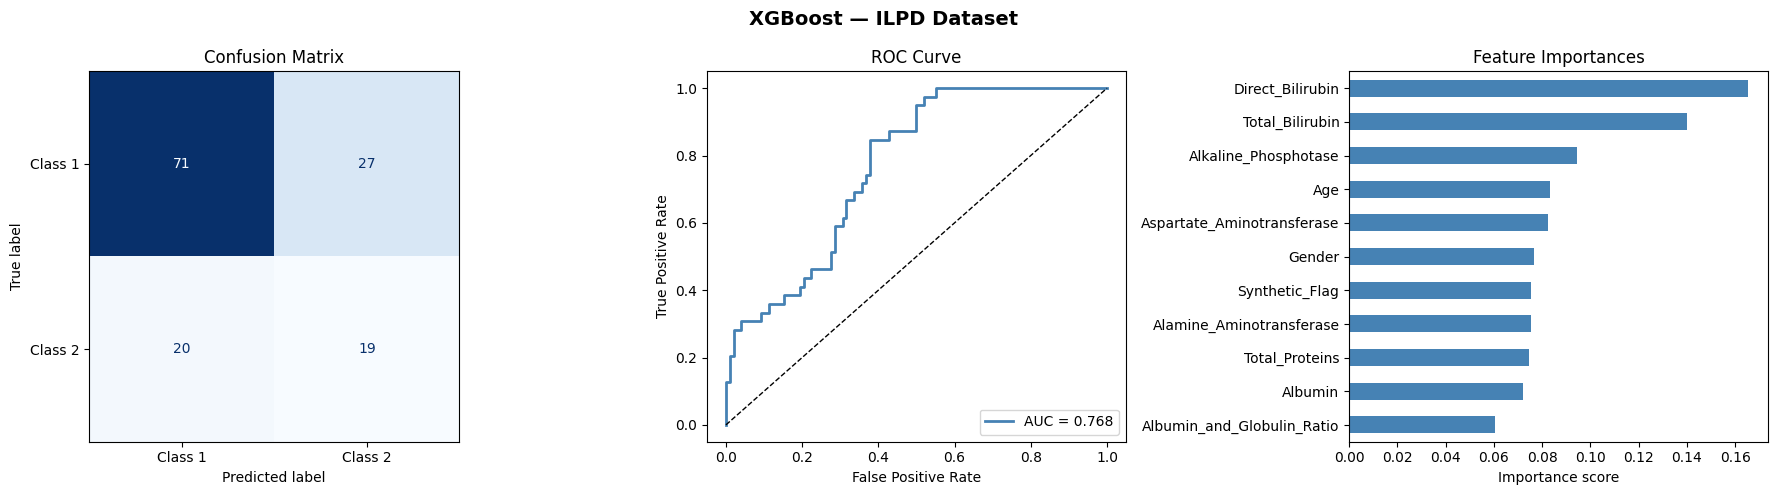


Plot saved to: xgboost_ilpd_results.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("XGBoost — ILPD Dataset", fontsize=14, fontweight="bold")

# — Confusion matrix —
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# — ROC curve —
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

# — Feature importances —
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh", ax=axes[2], color="steelblue")
axes[2].set_title("Feature Importances")
axes[2].set_xlabel("Importance score")

plt.tight_layout()
plt.savefig("xgboost_ilpd_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved to: xgboost_ilpd_results.png")

In [11]:
def objective(trial):
    """Optuna objective: 5-fold CV F1-weighted on the TRAINING set only."""
    params = {
        "n_estimators"      : trial.suggest_int("n_estimators", 100, 800),
        "max_depth"         : trial.suggest_int("max_depth", 3, 10),
        "learning_rate"     : trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "subsample"         : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree"  : trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "colsample_bylevel" : trial.suggest_float("colsample_bylevel", 0.4, 1.0),
        "min_child_weight"  : trial.suggest_int("min_child_weight", 1, 20),
        "gamma"             : trial.suggest_float("gamma", 0.0, 2.0),
        "reg_alpha"         : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"        : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "max_delta_step"    : trial.suggest_int("max_delta_step", 0, 10),
        "scale_pos_weight"  : scale_pos_weight,
        "eval_metric"       : "logloss",
        "random_state"      : RANDOM_SEED,
        "n_jobs"            : -1,
    }

    cv_scores = []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr  = X_train.iloc[tr_idx];  X_val = X_train.iloc[val_idx]
        y_tr  = y_train[tr_idx];       y_val = y_train[val_idx]

        clf = XGBClassifier(**params)
        clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        score = f1_score(y_val, clf.predict(X_val), average="weighted", zero_division=0)
        cv_scores.append(score)

        # Report for pruner (kills unpromising trials early)
        trial.report(np.mean(cv_scores), fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(cv_scores)


print("=" * 55)
print("  PHASE 2 — OPTUNA BAYESIAN TUNING (100 trials)")
print("=" * 55)

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)          # reproducible
pruner  = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=1)

study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\n  Completed trials : {len(study.trials)}")
print(f"  Pruned   trials  : {sum(t.state == optuna.trial.TrialState.PRUNED for t in study.trials)}")
print(f"  Best CV F1-weighted: {study.best_value:.4f}")
print("\n  Best params found:")
for k, v in study.best_params.items():
    print(f"    {k:25s}: {v}")

  PHASE 2 — OPTUNA BAYESIAN TUNING (100 trials)


  0%|          | 0/100 [00:00<?, ?it/s]


  Completed trials : 100
  Pruned   trials  : 58
  Best CV F1-weighted: 0.7220

  Best params found:
    n_estimators             : 461
    max_depth                : 10
    learning_rate            : 0.046521265728144835
    subsample                : 0.7218889181845154
    colsample_bytree         : 0.7831754418179878
    colsample_bylevel        : 0.4688276278214509
    min_child_weight         : 1
    gamma                    : 1.065113632071947
    reg_alpha                : 0.5371045783726767
    reg_lambda               : 1.167942035185509
    max_delta_step           : 4


In [12]:
best_params = study.best_params.copy()
best_params.update({
    "scale_pos_weight" : scale_pos_weight,
    "eval_metric"      : "logloss",
    "random_state"     : RANDOM_SEED,
    "n_jobs"           : -1,
})

tuned_model = XGBClassifier(**best_params)

# Cross-validate tuned model on training data only
tuned_cv = cross_validate(
    tuned_model, X_train, y_train,
    cv=skf,
    scoring=["accuracy", "f1_weighted", "roc_auc"],
    return_train_score=True,
)

print("=" * 55)
print("  PHASE 3 — TUNED MODEL EVALUATION")
print("=" * 55)
print("\n  5-Fold CV Results (Tuned, on training data):")
print(f"  Accuracy   : {tuned_cv['test_accuracy'].mean():.4f} \u00b1 {tuned_cv['test_accuracy'].std():.4f}")
print(f"  F1-weighted: {tuned_cv['test_f1_weighted'].mean():.4f} \u00b1 {tuned_cv['test_f1_weighted'].std():.4f}")
print(f"  ROC-AUC    : {tuned_cv['test_roc_auc'].mean():.4f} \u00b1 {tuned_cv['test_roc_auc'].std():.4f}")

# Final fit on full training set, evaluate on held-out test set
tuned_model.fit(X_train, y_train)
tuned_pred      = tuned_model.predict(X_test)
tuned_pred_prob = tuned_model.predict_proba(X_test)[:, 1]
tuned_acc       = accuracy_score(y_test, tuned_pred)
tuned_auc       = roc_auc_score(y_test, tuned_pred_prob)

print(f"\n  Test Accuracy : {tuned_acc:.4f}  ({tuned_acc*100:.2f}%)")
print(f"  Test ROC-AUC  : {tuned_auc:.4f}")
print("\n  Classification Report (Tuned):")
print(classification_report(y_test, tuned_pred, target_names=target_names, zero_division=0))

  PHASE 3 — TUNED MODEL EVALUATION

  5-Fold CV Results (Tuned, on training data):
  Accuracy   : 0.7167 ± 0.0330
  F1-weighted: 0.7220 ± 0.0283
  ROC-AUC    : 0.7567 ± 0.0327

  Test Accuracy : 0.7007  (70.07%)
  Test ROC-AUC  : 0.7718

  Classification Report (Tuned):
              precision    recall  f1-score   support

     Class 1       0.81      0.76      0.78        98
     Class 2       0.48      0.56      0.52        39

    accuracy                           0.70       137
   macro avg       0.65      0.66      0.65       137
weighted avg       0.72      0.70      0.71       137

